## 1. Load Data

In [170]:
import pandas as pd

In [171]:
df = pd.read_csv("clean_Data/demo_exp_merged.csv")

In [172]:
df.head()

,client_id,client_tenure_yr,client_tenure_month,client_age,gender,num_accts,balance,calls_6_mnth,logons_6_mnth,Variation
0,836976,6.0,73.0,60,Unknown,2,45105.30,6,9,Test
1,2304905,7.0,94.0,58,Unknown,2,110860.30,6,9,Control
2,1439522,5.0,64.0,32,Unknown,2,52467.79,6,9,Test
3,1562045,16.0,198.0,49,Male,2,67454.65,3,6,Test
4,5126305,12.0,145.0,33,Female,2,103671.75,0,3,Control


In [173]:
df['client_id'].duplicated().sum()

np.int64(0)

In [174]:
df['Variation'].isna().sum()

np.int64(0)

In [175]:
df['client_age'].describe()

count    50485.000000
mean        47.323324
std         15.522202
min         17.000000
25%         34.000000
50%         48.000000
75%         60.000000
max         96.000000
Name: client_age, dtype: float64

The minimum age is 17 and maximum age is 96

In [176]:
df['gender'].value_counts()

gender
Unknown    17280
Male       16947
Female     16258
Name: count, dtype: int64

The male and female are almost equal .so is number of people whose identity is unknown.

In [177]:
df['num_accts'].describe()

count    50485.000000
mean         2.254590
std          0.533683
min          1.000000
25%          2.000000
50%          2.000000
75%          2.000000
max          7.000000
Name: num_accts, dtype: float64

Minimum number of account is 1 while a person has maximum of 7 accounts.

## 2. Creating categories

In [178]:
df['age_group'] = pd.cut(
    df['client_age'],
    bins=[18, 34, 48, 60, 90],
    labels=['Young', 'Middle', 'Senior', 'Elders']
)

In [181]:
df['age_group'].value_counts()

age_group
Young     13633
Senior    13131
Middle    12027
Elders    11421
Name: count, dtype: int64

In [192]:
df.groupby(['Variation', 'age_group']).size().reset_index(name='count')

C:\Users\HP\AppData\Local\Temp\ipykernel_20784\2133751707.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Variation', 'age_group']).size().reset_index(name='count')


,Variation,age_group,count
0,Control,Young,6251
1,Control,Middle,5588
2,Control,Senior,6156
3,Control,Elders,5409
4,Test,Young,7382
5,Test,Middle,6439
6,Test,Senior,6975
7,Test,Elders,6012


Number of youngers in age group 18-34 is slightly higher than all other groups.While elders from 60-90 are lowest.

In [179]:
df['tenure_group'] = pd.cut(df['client_tenure_yr'],bins=[0,5,10,100],labels=['New','Mid','Long'])

In [180]:
df['tenure_group'].value_counts()

tenure_group
Long    25782
Mid     15974
New      8729
Name: count, dtype: int64

New clients are less as compared to long lasting or trusted customers.

In [155]:
df.head()

,client_id,client_tenure_yr,client_tenure_month,client_age,gender,num_accts,balance,calls_6_mnth,logons_6_mnth,Variation,age_group,tenure_group
0,836976,6.0,73.0,60,Unknown,2,45105.30,6,9,Test,Senior,Mid
1,2304905,7.0,94.0,58,Unknown,2,110860.30,6,9,Control,Senior,Mid
2,1439522,5.0,64.0,32,Unknown,2,52467.79,6,9,Test,Young,New
3,1562045,16.0,198.0,49,Male,2,67454.65,3,6,Test,Senior,Long
4,5126305,12.0,145.0,33,Female,2,103671.75,0,3,Control,Young,Long


## Analysis
1. Overall analysis

In [ ]:
df['Variation'].value_counts()

Variation
Test       26959
Control    23526
Name: count, dtype: int64

The number of customer for Test and control are almost equal. 

Test-26959
Control-23526

In [162]:
df.groupby('Variation')[['calls_6_mnth','logons_6_mnth','balance','num_accts']].mean()

,calls_6_mnth,logons_6_mnth,balance,num_accts
Variation,,,,
Control,3.129176,6.166242,150151.900186,2.259925
Test,3.061909,6.101821,148971.548521,2.249935


## Segment level analysis
1. By age group

In [159]:
df['age_group'].value_counts()

age_group
Young     13633
Senior    13131
Middle    12027
Elders    11421
Name: count, dtype: int64

In [163]:
df.groupby(['Variation','age_group'])[['logons_6_mnth','calls_6_mnth','balance']].mean()

C:\Users\HP\AppData\Local\Temp\ipykernel_20784\493621250.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Variation','age_group'])[['logons_6_mnth','calls_6_mnth','balance']].mean()


logons_6_mnth  calls_6_mnth        balance
Variation age_group                                            
Control   Young           6.230843      3.210846   70511.584065
          Middle          5.889764      2.864889  130217.530642
          Senior          6.077485      3.038012  177808.960625
          Elders          6.496765      3.429839  232887.226423
Test      Young           6.099025      3.076808   70073.310312
          Middle          5.849821      2.820935  125791.099158
          Senior          6.070108      3.031971  180028.801880
          Elders          6.422821      3.347139  236953.603076

## Segment level analysis
By tenure group

In [158]:
df['tenure_group'].value_counts()

tenure_group
Long    25782
Mid     15974
New      8729
Name: count, dtype: int64

In [164]:
df.groupby(['Variation','tenure_group'])[['logons_6_mnth','calls_6_mnth','balance']].mean()

C:\Users\HP\AppData\Local\Temp\ipykernel_20784\1095365754.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Variation','tenure_group'])[['logons_6_mnth','calls_6_mnth','balance']].mean()


logons_6_mnth  calls_6_mnth        balance
Variation tenure_group                                            
Control   New                6.129453      3.102107   91390.938801
          Mid                6.154293      3.124460  116690.181327
          Long               6.185625      3.140950  189890.245503
Test      New                6.080329      3.043222   89321.776485
          Mid                6.074247      3.040509  118085.986170
          Long               6.126593      3.081832  189080.310122

## Segment level analysis
By gender

In [191]:
df.groupby(['Variation', 'gender']).size().reset_index(name='count')

,Variation,gender,count
0,Control,Female,7542
1,Control,Male,7970
2,Control,Unknown,8014
3,Test,Female,8716
4,Test,Male,8977
5,Test,Unknown,9266


In [165]:
df.groupby(['Variation','gender'])[['logons_6_mnth','calls_6_mnth','balance']].mean()

logons_6_mnth  calls_6_mnth        balance
Variation gender                                             
Control   Female        5.872845      2.823389  137175.199845
          Male          6.493852      3.458093  216052.399516
          Unknown       6.116546      3.089843   96825.632942
Test      Female        5.830656      2.778224  140732.026165
          Male          6.435446      3.399911  209860.638476
          Unknown       6.033671      3.001295   97731.997077

## Visualization
Overall comparison bar plot

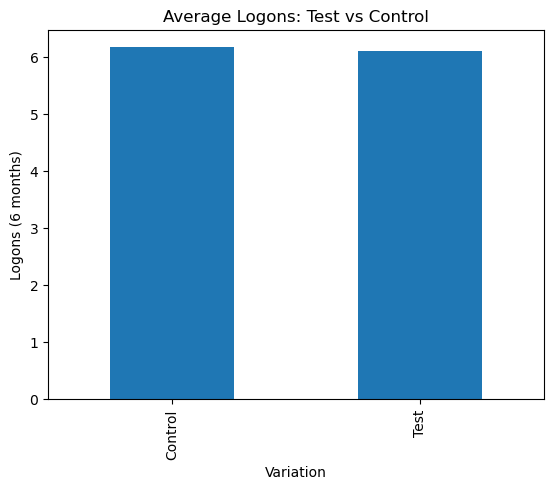

In [166]:
import matplotlib.pyplot as plt

df.groupby('Variation')['logons_6_mnth'].mean().plot(kind='bar')
plt.title('Average Logons: Test vs Control')
plt.ylabel('Logons (6 months)')
plt.show()

Who are primary clients

In [183]:
df.groupby('age_group',observed=True)['logons_6_mnth'].sum()

age_group
Young     83972
Middle    70579
Senior    79752
Elders    73755
Name: logons_6_mnth, dtype: int64

In [184]:
df.groupby('age_group',observed=True)['calls_6_mnth'].sum()

age_group
Young     42784
Middle    34173
Senior    39850
Elders    38675
Name: calls_6_mnth, dtype: int64

Young clients are the most active users of the online process, while Middle aged  clients show slightly lower engagement. Young client use online as well as offline process more.

In [185]:
# Gender wise
df.groupby('gender')['logons_6_mnth'].sum()

gender
Female      95113
Male       109527
Unknown    104926
Name: logons_6_mnth, dtype: int64

In [186]:
(df['gender'].value_counts(normalize=True)*100).round(1)

gender
Unknown    34.2
Male       33.6
Female     32.2
Name: proportion, dtype: float64

Male usng online format are more as compared to women. Almost 1/3 rd the people do not wish to disclose their identity

Long term client tend to use online format more as compared to new client.

People having higher balance login more as compared to other users.


## 2. Conclusions

1 Who are primary clients?

 Clients in the “Middle” and “Senior” age groups use the online process the most.

2 Younger or older?

 Older clients show higher usage compared to younger clients.

3 New or long-standing?

Long-standing clients are more active than new clients.

C:\Users\HP\AppData\Local\Temp\ipykernel_20784\3941139652.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_age = df.groupby(['age_group', 'Variation'])['logons_6_mnth'].mean().unstack()


<Figure size 640x480 with 0 Axes>

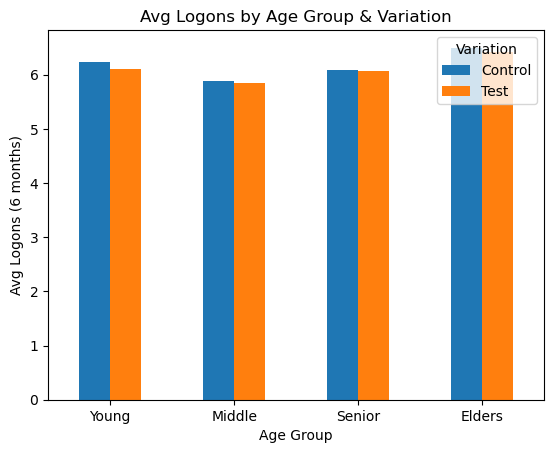

In [157]:
import matplotlib.pyplot as plt

pivot_age = df.groupby(['age_group', 'Variation'])['logons_6_mnth'].mean().unstack()

plt.figure()
pivot_age.plot(kind='bar')
plt.title('Avg Logons by Age Group & Variation')
plt.xlabel('Age Group')
plt.ylabel('Avg Logons (6 months)')
plt.xticks(rotation=0)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_20784\799507638.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_tenure = df.groupby(['tenure_group', 'Variation'])['logons_6_mnth'].mean().unstack()


<Figure size 640x480 with 0 Axes>

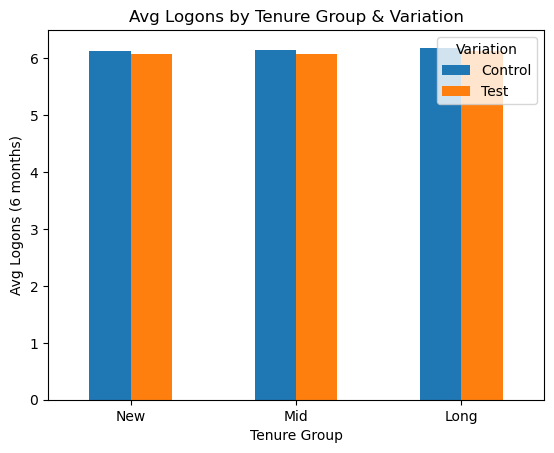

In [160]:
pivot_tenure = df.groupby(['tenure_group', 'Variation'])['logons_6_mnth'].mean().unstack()

plt.figure()
pivot_tenure.plot(kind='bar')
plt.title('Avg Logons by Tenure Group & Variation')
plt.xlabel('Tenure Group')
plt.ylabel('Avg Logons (6 months)')
plt.xticks(rotation=0)
plt.show()